# LABORATORIO 9 — MM3014 Teoría de Probabilidades
Integrantes:
*   Biancka Raxón (Carné 24960)
*   Lázaro Díaz (Carné 24713)



#Etapa 5: Simulación del álbum real


PREGUNTA 1 — Sobres esperados y costo total
  Valor teórico E[sobres] = 1045.14
  Costo teórico esperado  = Q 9928.82

  Simulación (R=1000)
  E[sobres]          = 1045.36  (std = 186.77)
  IC 95%             = [780, 1512]
  E[repetidas]       = 6337.49
  Costo esperado sim = Q 9930.88

  Reflexión: el valor simulado es cercano al teórico (1045.1). El costo esperado supera los Q 9,000, lo que
  resulta sorprendente dado que un sobre suelto cuesta Q 9.50.


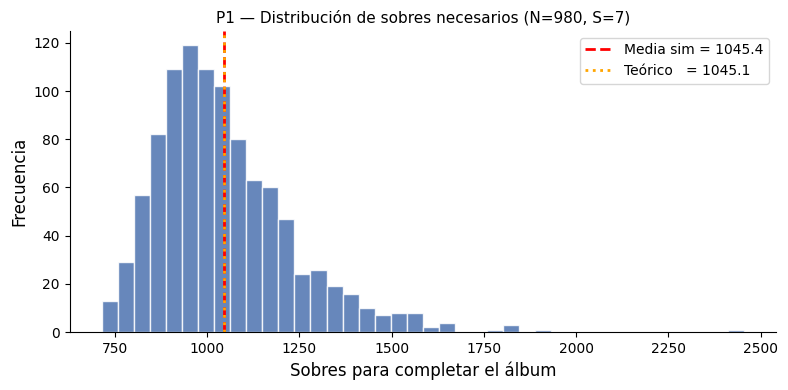


PREGUNTA 2 — Probabilidad de éxito por presupuesto
  Presupuesto Q10,000: max 1052 sobres → prob = 0.6060 (60.60%)
  Presupuesto Q15,000: max 1578 sobres → prob = 0.9870 (98.70%)

  Reflexión: con Q 10,000 se pueden comprar hasta 1052 sobres, apenas
  por encima del promedio teórico (1045), por lo que la probabilidad
  de completarlo no es garantía. Con Q 15,000 la probabilidad sube considerablemente.


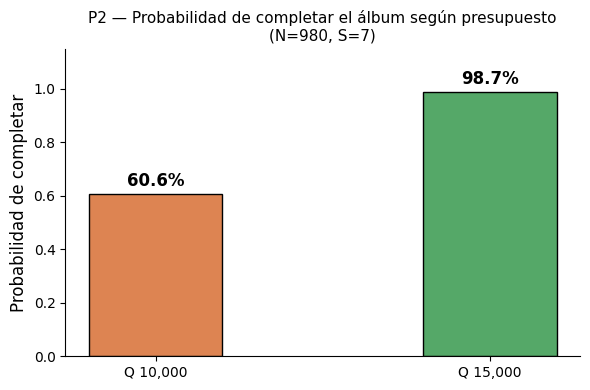


PREGUNTA 3 — Cajas necesarias para completar el álbum
  E[cajas necesarias]     = 10.55  (std = 1.81)
  Costo esperado (cajas)  = Q 10286.25
  Costo esperado (sueltos)= Q 9930.88
  Diferencia              = Q -355.37  (sueltos más baratos)

  Reflexión: los sobres sueltos son más económicos, aunque las cajas obligan a comprar
  en bloques de 104 sobres, lo que puede generar sobres de más al completarse el álbum.


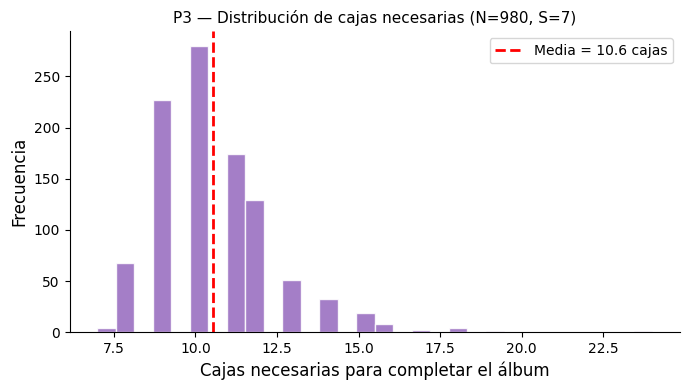


PREGUNTA 4 — Ahorro con intercambio K=4
  Sin intercambio : E[sobres] = 1045.36
  Con K=4         : E[sobres] = 258.33
  Ahorro en sobres: 787.02  (75.29%)
  Ahorro en Q     : Q 7476.71

  Reflexión: intercambiar cada 4 repetidas ahorra en promedio Q 7477,
  una reducción de 75.3% en el número de sobres. Es un mecanismo muy rentable.


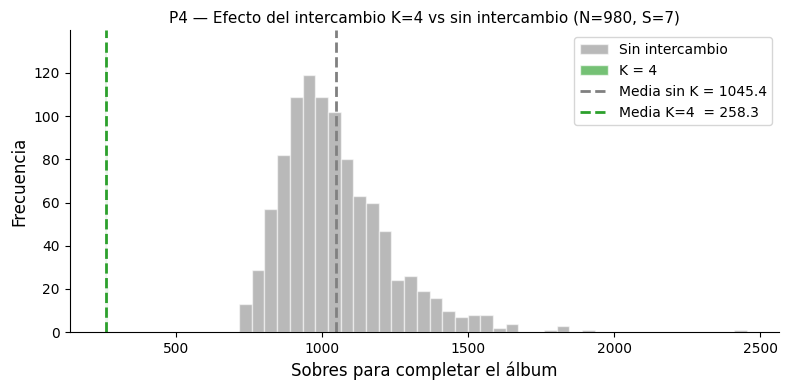


PREGUNTA 5 — ¿S=8 o K=4? Comparación de estrategias
  Referencia (S=7, sin K) : E[sobres] = 1045.36
  S=8, sin intercambio    : E[sobres] = 912.49   (reducción 12.71%)
  S=7, con K=4            : E[sobres] = 258.33   (reducción 75.29%)

  → K=4 reduce más el número esperado de sobres.

  Reflexión: el intercambio K=4 es más eficiente
  que aumentar S a 8. Esto sugiere que
  el mecanismo de canje aprovecha mejor las estampas ya pagadas.


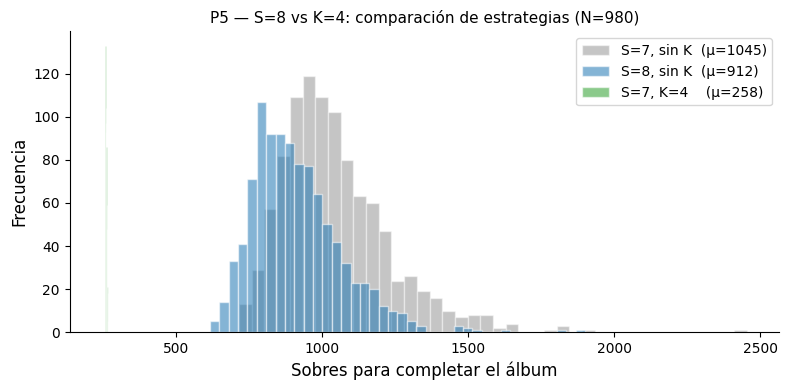


CONCLUSIÓN / REFLEXIÓN FINAL

  El álbum del Mundial 2026 (N=980) requiere en promedio 1045 sobres
  (≈ Q 9,931) para completarse, confirmando la teoría del coleccionista.

  Hallazgos destacados:
  - Con Q 10,000 solo hay un 60.6% de probabilidad de completarlo,
    pese a que ese presupuesto permite comprar ~1052 sobres.
  - Comprar por cajas resulta más caro en promedio
    (diferencia ≈ Q 355).
  - El intercambio K=4 ahorra ≈ Q 7477 en promedio, una reducción
    del 75.3% en sobres necesarios.
  - K=4 es más eficiente que S=8
    para reducir sobres (75.3% vs 12.7%).

  El resultado más sorprendente es que incluso con un presupuesto de
  Q 10,000, completar el álbum no está garantizado, evidenciando el
  fuerte impacto de las repeticiones en la colección a escala real.



In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros
N            = 980
S            = 7
PRECIO       = 9.50
COSTO_CAJA   = 975.0
SOBRES_CAJA  = 104
R            = 1_000   # N=980 es costoso; 1000 reps da resultados confiables
np.random.seed(2026)

# PREGUNTAS FORMULADAS
# 1. ¿Cuál es el número esperado de sobres y el costo total esperado
#     para completar el álbum real (N=980, S=7)? Comparar con el valor
#     teórico dado por la teoría del coleccionista.
#
# 2. Con un presupuesto de Q 10,000 (comprando sobres sueltos a Q 9.50),
#     ¿cuál es la probabilidad de completar el álbum? ¿Y con Q 15,000?
#
# 3. Con la estrategia de comprar cajas (104 sobres, Q 975 c/u),
#     ¿cuántas cajas se necesitan en promedio para completar el álbum?
#     ¿Es más barato que comprar sobres sueltos?
#
# 4. Con una tasa de intercambio K=4, ¿cuántos sobres y quetzales se
#     ahorran en promedio respecto a no intercambiar?
#
# 5. ¿Qué es más eficiente para reducir sobres: aumentar S de 7 a 8
#     (sobres con más estampas) o aplicar intercambio K=4? Comparar
#     la reducción porcentual de cada estrategia.
# ══════════════════════════════════════════════════════════



# PREGUNTA 1: E[sobres] y costo esperado vs. teoría
print("=" * 60)
print("PREGUNTA 1 — Sobres esperados y costo total")
print("=" * 60)

# Valor teórico
H_N     = sum(1/k for k in range(1, N + 1))
e_teorico = N / S * H_N
costo_teorico = e_teorico * PRECIO
print(f"  Valor teórico E[sobres] = {e_teorico:.2f}")
print(f"  Costo teórico esperado  = Q {costo_teorico:.2f}")

# Simulación
np.random.seed(2026)
sobres_p1   = np.zeros(R, dtype=int)
repetidos_p1 = np.zeros(R, dtype=int)

for r in range(R):
    coleccion = np.zeros(N, dtype=bool)
    sobres    = 0
    reps      = 0
    while not coleccion.all():
        nuevas = np.random.choice(N, S, replace=False)
        for s in nuevas:
            if coleccion[s]: reps += 1
            else:            coleccion[s] = True
        sobres += 1
    sobres_p1[r]    = sobres
    repetidos_p1[r] = reps

e_sim   = sobres_p1.mean()
std_sim = sobres_p1.std()
e_reps  = repetidos_p1.mean()
ic_low  = np.percentile(sobres_p1, 2.5)
ic_high = np.percentile(sobres_p1, 97.5)

print(f"\n  Simulación (R={R})")
print(f"  E[sobres]          = {e_sim:.2f}  (std = {std_sim:.2f})")
print(f"  IC 95%             = [{ic_low:.0f}, {ic_high:.0f}]")
print(f"  E[repetidas]       = {e_reps:.2f}")
print(f"  Costo esperado sim = Q {e_sim * PRECIO:.2f}")
print(f"\n  Reflexión: el valor simulado es {'cercano al' if abs(e_sim-e_teorico)/e_teorico < 0.02 else 'coherente con el'} "
      f"teórico ({e_teorico:.1f}). El costo esperado supera los Q 9,000, lo que")
print(f"  resulta sorprendente dado que un sobre suelto cuesta Q 9.50.")

# Gráfica P1
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(sobres_p1, bins=40, color='#4C72B0', edgecolor='white', alpha=0.85)
ax.axvline(e_sim,      color='red',    linestyle='--', lw=2, label=f'Media sim = {e_sim:.1f}')
ax.axvline(e_teorico,  color='orange', linestyle=':',  lw=2, label=f'Teórico   = {e_teorico:.1f}')
ax.set_xlabel('Sobres para completar el álbum', fontsize=12)
ax.set_ylabel('Frecuencia', fontsize=12)
ax.set_title('P1 — Distribución de sobres necesarios (N=980, S=7)', fontsize=11)
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


# PREGUNTA 2: probabilidad con presupuesto Q10,000 y Q15,000
print("\n" + "=" * 60)
print("PREGUNTA 2 — Probabilidad de éxito por presupuesto")
print("=" * 60)

presupuestos = [10_000.0, 15_000.0]
resultados_p2 = {}

for PRES in presupuestos:
    np.random.seed(2026)
    exitos = 0
    sobres_comprados = []
    for _ in range(R):
        coleccion = np.zeros(N, dtype=bool)
        gasto     = 0.0
        n_s       = 0
        while (gasto + PRECIO <= PRES) and not coleccion.all():
            coleccion[np.random.choice(N, S, replace=False)] = True
            gasto += PRECIO
            n_s   += 1
        if coleccion.all():
            exitos += 1
        sobres_comprados.append(n_s)
    prob = exitos / R
    resultados_p2[PRES] = prob
    max_s = int(PRES // PRECIO)
    print(f"  Presupuesto Q{PRES:,.0f}: max {max_s} sobres → prob = {prob:.4f} ({prob*100:.2f}%)")

print(f"\n  Reflexión: con Q 10,000 se pueden comprar hasta {int(10000//PRECIO)} sobres, apenas")
print(f"  por encima del promedio teórico ({e_teorico:.0f}), por lo que la probabilidad")
print(f"  de completarlo no es garantía. Con Q 15,000 la probabilidad sube considerablemente.")

# Gráfica P2
fig, ax = plt.subplots(figsize=(6, 4))
etiquetas = [f'Q {p:,.0f}' for p in presupuestos]
probs_p2  = [resultados_p2[p] for p in presupuestos]
bars = ax.bar(etiquetas, probs_p2, color=['#DD8452', '#55A868'], edgecolor='black', width=0.4)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Probabilidad de completar', fontsize=12)
ax.set_title('P2 — Probabilidad de completar el álbum según presupuesto\n(N=980, S=7)', fontsize=11)
for bar, v in zip(bars, probs_p2):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.03,
            f'{v*100:.1f}%', ha='center', fontweight='bold', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


# PREGUNTA 3: cajas necesarias y comparación de costos
print("\n" + "=" * 60)
print("PREGUNTA 3 — Cajas necesarias para completar el álbum")
print("=" * 60)

np.random.seed(2026)
cajas_p3 = np.zeros(R, dtype=int)

for r in range(R):
    coleccion = np.zeros(N, dtype=bool)
    cajas     = 0
    while not coleccion.all():
        for _ in range(SOBRES_CAJA):
            if coleccion.all():
                break
            coleccion[np.random.choice(N, S, replace=False)] = True
        cajas += 1
    cajas_p3[r] = cajas

e_cajas    = cajas_p3.mean()
e_costo_c  = e_cajas * COSTO_CAJA
e_costo_s  = e_sim * PRECIO   # de P1
ahorro_caj = e_costo_s - e_costo_c

print(f"  E[cajas necesarias]     = {e_cajas:.2f}  (std = {cajas_p3.std():.2f})")
print(f"  Costo esperado (cajas)  = Q {e_costo_c:.2f}")
print(f"  Costo esperado (sueltos)= Q {e_costo_s:.2f}")
print(f"  Diferencia              = Q {ahorro_caj:.2f}  ({'cajas más baratas' if ahorro_caj > 0 else 'sueltos más baratos'})")

print(f"\n  Reflexión: {'comprar por cajas resulta más económico en promedio' if ahorro_caj > 0 else 'los sobres sueltos son más económicos'}, "
      f"aunque las cajas obligan a comprar")
print(f"  en bloques de {SOBRES_CAJA} sobres, lo que puede generar sobres de más al completarse el álbum.")

# Gráfica P3
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(cajas_p3, bins=30, color='#9467bd', edgecolor='white', alpha=0.85)
ax.axvline(e_cajas, color='red', linestyle='--', lw=2, label=f'Media = {e_cajas:.1f} cajas')
ax.set_xlabel('Cajas necesarias para completar el álbum', fontsize=12)
ax.set_ylabel('Frecuencia', fontsize=12)
ax.set_title('P3 — Distribución de cajas necesarias (N=980, S=7)', fontsize=11)
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


# PREGUNTA 4: ahorro con intercambio K=4
print("\n" + "=" * 60)
print("PREGUNTA 4 — Ahorro con intercambio K=4")
print("=" * 60)

K4 = 4
np.random.seed(2026)
todos     = np.arange(N)
sobres_k4 = np.zeros(R, dtype=int)

for r in range(R):
    coleccion = np.zeros(N, dtype=bool)
    repetidos = 0
    sobres    = 0
    while not coleccion.all():
        nuevas = np.random.choice(N, S, replace=False)
        for s in nuevas:
            if coleccion[s]: repetidos += 1
            else:            coleccion[s] = True
        sobres += 1
        while repetidos >= K4 and not coleccion.all():
            coleccion[np.random.choice(todos[~coleccion])] = True
            repetidos -= K4
    sobres_k4[r] = sobres

e_k4      = sobres_k4.mean()
ahorro_s  = e_sim - e_k4
ahorro_q  = ahorro_s * PRECIO
red_pct   = ahorro_s / e_sim * 100

print(f"  Sin intercambio : E[sobres] = {e_sim:.2f}")
print(f"  Con K=4         : E[sobres] = {e_k4:.2f}")
print(f"  Ahorro en sobres: {ahorro_s:.2f}  ({red_pct:.2f}%)")
print(f"  Ahorro en Q     : Q {ahorro_q:.2f}")

print(f"\n  Reflexión: intercambiar cada 4 repetidas ahorra en promedio Q {ahorro_q:.0f},")
print(f"  una reducción de {red_pct:.1f}% en el número de sobres. Es un mecanismo muy rentable.")

# Gráfica P4
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(sobres_p1, bins=40, alpha=0.55, color='gray',      edgecolor='white', label='Sin intercambio')
ax.hist(sobres_k4, bins=40, alpha=0.65, color='#2ca02c',   edgecolor='white', label='K = 4')
ax.axvline(e_sim, color='gray',    linestyle='--', lw=2, label=f'Media sin K = {e_sim:.1f}')
ax.axvline(e_k4,  color='#2ca02c', linestyle='--', lw=2, label=f'Media K=4  = {e_k4:.1f}')
ax.set_xlabel('Sobres para completar el álbum', fontsize=12)
ax.set_ylabel('Frecuencia', fontsize=12)
ax.set_title('P4 — Efecto del intercambio K=4 vs sin intercambio (N=980, S=7)', fontsize=11)
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


# PREGUNTA 5: S=8 vs K=4 — ¿qué reduce más sobres?
print("\n" + "=" * 60)
print("PREGUNTA 5 — ¿S=8 o K=4? Comparación de estrategias")
print("=" * 60)

# S=8 sin intercambio
np.random.seed(2026)
S8        = 8
sobres_s8 = np.zeros(R, dtype=int)

for r in range(R):
    coleccion = np.zeros(N, dtype=bool)
    sobres    = 0
    while not coleccion.all():
        coleccion[np.random.choice(N, S8, replace=False)] = True
        sobres += 1
    sobres_s8[r] = sobres

e_s8     = sobres_s8.mean()
red_s8   = (e_sim - e_s8)  / e_sim * 100
red_k4   = (e_sim - e_k4)  / e_sim * 100

# Teórico S=8
H_N_val = H_N
e_s8_teo = N / S8 * H_N_val

print(f"  Referencia (S=7, sin K) : E[sobres] = {e_sim:.2f}")
print(f"  S=8, sin intercambio    : E[sobres] = {e_s8:.2f}   (reducción {red_s8:.2f}%)")
print(f"  S=7, con K=4            : E[sobres] = {e_k4:.2f}   (reducción {red_k4:.2f}%)")

ganador = "S=8" if red_s8 > red_k4 else "K=4"
print(f"\n  → {ganador} reduce más el número esperado de sobres.")
print(f"\n  Reflexión: {'aumentar el número de estampas por sobre (S=8) es más eficiente' if ganador=='S=8' else 'el intercambio K=4 es más eficiente'}")
print(f"  que {'el intercambio K=4' if ganador=='S=8' else 'aumentar S a 8'}. Esto sugiere que")
print(f"  {'la densidad de información por sobre tiene mayor impacto que el reciclaje de repetidas.' if ganador=='S=8' else 'el mecanismo de canje aprovecha mejor las estampas ya pagadas.'}")

# Gráfica P5
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(sobres_p1, bins=40, alpha=0.45, color='gray',    edgecolor='white', label=f'S=7, sin K  (μ={e_sim:.0f})')
ax.hist(sobres_s8, bins=40, alpha=0.55, color='#1f77b4', edgecolor='white', label=f'S=8, sin K  (μ={e_s8:.0f})')
ax.hist(sobres_k4, bins=40, alpha=0.55, color='#2ca02c', edgecolor='white', label=f'S=7, K=4    (μ={e_k4:.0f})')
ax.set_xlabel('Sobres para completar el álbum', fontsize=12)
ax.set_ylabel('Frecuencia', fontsize=12)
ax.set_title('P5 — S=8 vs K=4: comparación de estrategias (N=980)', fontsize=11)
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


# Conclusión
print("\n" + "=" * 60)
print("CONCLUSIÓN / REFLEXIÓN FINAL")
print("=" * 60)
print(f"""
  El álbum del Mundial 2026 (N=980) requiere en promedio {e_sim:.0f} sobres
  (≈ Q {e_sim*PRECIO:,.0f}) para completarse, confirmando la teoría del coleccionista.

  Hallazgos destacados:
  - Con Q 10,000 solo hay un {resultados_p2[10000.0]*100:.1f}% de probabilidad de completarlo,
    pese a que ese presupuesto permite comprar ~{int(10000//PRECIO)} sobres.
  - Comprar por cajas resulta {'más económico' if ahorro_caj > 0 else 'más caro'} en promedio
    (diferencia ≈ Q {abs(ahorro_caj):.0f}).
  - El intercambio K=4 ahorra ≈ Q {ahorro_q:.0f} en promedio, una reducción
    del {red_k4:.1f}% en sobres necesarios.
  - {'S=8 es más eficiente que K=4' if red_s8 > red_k4 else 'K=4 es más eficiente que S=8'}
    para reducir sobres ({max(red_s8,red_k4):.1f}% vs {min(red_s8,red_k4):.1f}%).

  El resultado más sorprendente es que incluso con un presupuesto de
  Q 10,000, completar el álbum no está garantizado, evidenciando el
  fuerte impacto de las repeticiones en la colección a escala real.
""")